## 프로젝트 개요 및 환경 설정

### 라이브러리 설치 및 Import

In [296]:
# 데이터 처리 및 분석
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import warnings

# 시각화
import matplotlib.pyplot as plt
import seaborn as sns

# 통계 분석
from scipy import stats
from scipy.stats import shapiro, levene, ttest_ind, chi2_contingency, f_oneway
from scipy.stats import mannwhitneyu, fisher_exact, kruskal
from statsmodels.stats.multicomp import pairwise_tukeyhsd, MultiComparison
import pingouin as pg

# 출력 설정
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)


# 한글 폰트 설정
import platform
if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif platform.system() == 'Darwin':  # maxOS
    plt.rcParams['font.family'] = 'AppleGothic'
else:  # Linux
    plt.rcParams['font.family'] = 'NanumGothic'
    
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.figsize'] = (12, 6)

# 시드 설정
np.random.seed(42)

print("="*60)
print("라이브러리 로드 완료!")
print("한글 폰트 설정 완료!")
print("="*60)

라이브러리 로드 완료!
한글 폰트 설정 완료!


### 데이터 로드

In [297]:
# 데이터 로드
df_transcript = pd.read_csv('../../Data/transcript.csv')
df_transcript.columns = df_transcript.columns.str.strip()

df_portfolio = pd.read_csv('../../Data/portfolio.csv')
df_portfolio.columns = df_portfolio.columns.str.strip()

df_profile = pd.read_csv('../../Data/profile.csv')
df_profile.columns = df_profile.columns.str.strip()

print("="*60)
print("데이터 로드 완료!")
print("="*60)

데이터 로드 완료!


## 데이터 이해

### 데이터 구조 파악

In [298]:
print("\n" + "="*60)
print("transcript 데이터")
print("="*60)
print(f"\ntranscript: {df_transcript.shape}")
print("\n[Data Info]")
df_transcript.info()


transcript 데이터

transcript: (306534, 5)

[Data Info]
<class 'pandas.DataFrame'>
RangeIndex: 306534 entries, 0 to 306533
Data columns (total 5 columns):
 #   Column      Non-Null Count   Dtype
---  ------      --------------   -----
 0   Unnamed: 0  306534 non-null  int64
 1   person      306534 non-null  str  
 2   event       306534 non-null  str  
 3   value       306534 non-null  str  
 4   time        306534 non-null  int64
dtypes: int64(2), str(3)
memory usage: 11.7 MB


In [299]:
df_transcript.head()

,Unnamed: 0,person,event,value,time
0,0,78afa995795e4d85b5d9ceeca43f5fef,offer received,{'offer id': '9b98b8c7a33c4b65b9aebfe6a799e6d9'},0
1,1,a03223e636434f42ac4c3df47e8bac43,offer received,{'offer id': '0b1e1539f2cc45b7b9fa7c272da2e1d7'},0
2,2,e2127556f4f64592b11af22de27a7932,offer received,{'offer id': '2906b810c7d4411798c6938adc9daaa5'},0
3,3,8ec6ce2a7e7949b1bf142def7d0e0586,offer received,{'offer id': 'fafdcd668e3743c1bb461111dcafc2a4'},0
4,4,68617ca6246f4fbc85e91a2a49552598,offer received,{'offer id': '4d5c57ea9a6940dd891ad53e9dbe8da0'},0


In [300]:
print("\n" + "="*60)
print("portfolio 데이터")
print("="*60)
print(f"\nportfolio: {df_portfolio.shape}")
print("\n[Data Info]")
df_portfolio.info()


portfolio 데이터

portfolio: (10, 7)

[Data Info]
<class 'pandas.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   Unnamed: 0  10 non-null     int64
 1   reward      10 non-null     int64
 2   channels    10 non-null     str  
 3   difficulty  10 non-null     int64
 4   duration    10 non-null     int64
 5   offer_type  10 non-null     str  
 6   id          10 non-null     str  
dtypes: int64(4), str(3)
memory usage: 692.0 bytes


In [301]:
df_portfolio.head()

,Unnamed: 0,reward,channels,difficulty,duration,offer_type,id
0,0,10,"['email', 'mobile', 'social']",10,7,bogo,ae264e3637204a6fb9bb56bc8210ddfd
1,1,10,"['web', 'email', 'mobile', 'social']",10,5,bogo,4d5c57ea9a6940dd891ad53e9dbe8da0
2,2,0,"['web', 'email', 'mobile']",0,4,informational,3f207df678b143eea3cee63160fa8bed
3,3,5,"['web', 'email', 'mobile']",5,7,bogo,9b98b8c7a33c4b65b9aebfe6a799e6d9
4,4,5,"['web', 'email']",20,10,discount,0b1e1539f2cc45b7b9fa7c272da2e1d7


In [302]:
print("\n" + "="*60)
print("profile 데이터")
print("="*60)
print(f"\nprofile: {df_profile.shape}")
print("\n[Data Info]")
df_profile.info()


profile 데이터

profile: (17000, 6)

[Data Info]
<class 'pandas.DataFrame'>
RangeIndex: 17000 entries, 0 to 16999
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Unnamed: 0        17000 non-null  int64  
 1   gender            14825 non-null  str    
 2   age               17000 non-null  int64  
 3   id                17000 non-null  str    
 4   became_member_on  17000 non-null  int64  
 5   income            14825 non-null  float64
dtypes: float64(1), int64(3), str(2)
memory usage: 797.0 KB


In [303]:
df_profile.head()

,Unnamed: 0,gender,age,id,became_member_on,income
0,0,NaN,118,68be06ca386d4c31939f3a4f0e3dd783,20170212,NaN
1,1,F,55,0610b486422d4921ae7d2bf64640c50b,20170715,112000.0
2,2,NaN,118,38fe809add3b4fcf9315a9694bb96ff5,20180712,NaN
3,3,F,75,78afa995795e4d85b5d9ceeca43f5fef,20170509,100000.0
4,4,NaN,118,a03223e636434f42ac4c3df47e8bac43,20170804,NaN


### 인덱스 컬럼 제거

In [304]:
df_transcript = df_transcript.drop(columns=['Unnamed: 0'])
df_portfolio = df_portfolio.drop(columns=['Unnamed: 0'])
df_profile = df_profile.drop(columns=['Unnamed: 0'])

print("="*60)
print("인덱스 컬럼 제거 완료!")
print("="*60)

인덱스 컬럼 제거 완료!


In [305]:
df_transcript.head()

,person,event,value,time
0,78afa995795e4d85b5d9ceeca43f5fef,offer received,{'offer id': '9b98b8c7a33c4b65b9aebfe6a799e6d9'},0
1,a03223e636434f42ac4c3df47e8bac43,offer received,{'offer id': '0b1e1539f2cc45b7b9fa7c272da2e1d7'},0
2,e2127556f4f64592b11af22de27a7932,offer received,{'offer id': '2906b810c7d4411798c6938adc9daaa5'},0
3,8ec6ce2a7e7949b1bf142def7d0e0586,offer received,{'offer id': 'fafdcd668e3743c1bb461111dcafc2a4'},0
4,68617ca6246f4fbc85e91a2a49552598,offer received,{'offer id': '4d5c57ea9a6940dd891ad53e9dbe8da0'},0


### 컬럼별 의미 및 데이터 타입 확인

In [306]:
# =======================================================
# 스타벅스 주요 컬럼 설명
# =======================================================
# [transcript] 고객 행동 로그 테이블
# • person                        : 고객 ID (profile 데이터와 동일)
# • event                         : 기록 설명 (예: transaction, offer received, offer viewed 등)
#   - offer received: 고객이 프로모션을 받음
#   - offer viewed: 고객이 프로모션을 열람함
#   - offer completed: 고객이 프로모션 조건을 충족함
#   - transaction: 실제 결제가 발생함
# • value                         : (문자열 사전) - 레코드에 따라 제안 ID 또는 거래 금액 중 하나
# • time                          : 시간 (시 기준, t = 0 ~ 714 구간)
# =======================================================
# [portfolio] 프로모션 자체의 속성 테이블
# • reward                        : 제안 완료 시 지급되는 보상
# • channels                      : (문자열 목록) ['web', 'email', 'mobile', 'social']
# • difficulty                    : 제안 완료를 위한 최소 필요 금액
# • duration                      : 기간
# • offer_type                    : 제공 유형 (예: BOGO 1+1, 할인, 정보 제공)
# • id                            : 제안 ID
# =======================================================
# [profile] 고객 프로필 테이블
# • gender                        : 고객의 성별 (일부 항목에는 M 또는 F 대신 'O'가 포함되어 있을 수 있습니다.)
# • age                           : 고객의 연령
# • id                            : 고객 ID
# • became_member_on              : 고객이 앱 계정을 생성한 날짜
# • income                        : 고객의 소득

### 기초 통계량 확인

In [307]:
print("\n" + "="*60)
print("transcript 기초 통계")
print("="*60)
display(df_transcript.describe(include='all').T)


transcript 기초 통계


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
person,306534,17000,94de646f7b6041228ca7dec82adb97d2,51,NaN,NaN,NaN,NaN,NaN,NaN,NaN
event,306534,4,transaction,138953,NaN,NaN,NaN,NaN,NaN,NaN,NaN
value,306534,5121,{'offer id': '2298d6c36e964ae4a3e7e9706d1fb8c2'},14983,NaN,NaN,NaN,NaN,NaN,NaN,NaN
time,306534.0,NaN,NaN,NaN,366.38294,200.326314,0.0,186.0,408.0,528.0,714.0


In [308]:
print("\n" + "="*60)
print("portfolio 기초 통계")
print("="*60)
display(df_portfolio.describe(include='all').T)


portfolio 기초 통계


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
reward,10.0,NaN,NaN,NaN,4.2,3.583915,0.0,2.0,4.0,5.0,10.0
channels,10,4,"['web', 'email', 'mobile', 'social']",4,NaN,NaN,NaN,NaN,NaN,NaN,NaN
difficulty,10.0,NaN,NaN,NaN,7.7,5.831905,0.0,5.0,8.5,10.0,20.0
duration,10.0,NaN,NaN,NaN,6.5,2.321398,3.0,5.0,7.0,7.0,10.0
offer_type,10,3,bogo,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN
id,10,10,ae264e3637204a6fb9bb56bc8210ddfd,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [309]:
print("\n" + "="*60)
print("profile 기초 통계")
print("="*60)
display(df_profile.describe(include='all').T)


profile 기초 통계


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
gender,14825,3,M,8484,NaN,NaN,NaN,NaN,NaN,NaN,NaN
age,17000.0,NaN,NaN,NaN,62.531412,26.73858,18.0,45.0,58.0,73.0,118.0
id,17000,17000,68be06ca386d4c31939f3a4f0e3dd783,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
became_member_on,17000.0,NaN,NaN,NaN,20167034.234118,11677.499961,20130729.0,20160526.0,20170802.0,20171230.0,20180726.0
income,14825.0,NaN,NaN,NaN,65404.991568,21598.29941,30000.0,49000.0,64000.0,80000.0,120000.0


### 고유값 확인

In [310]:
print("\n" + "="*60)
print("transcript 컬럼별 고유값 개수")
print("="*60)
print(df_transcript.nunique())


transcript 컬럼별 고유값 개수
person    17000
event         4
value      5121
time        120
dtype: int64


> person 컬럼이 외래키?

In [311]:
print("\n" + "="*60)
print("portfolio 컬럼별 고유값 개수")
print("="*60)
print(df_portfolio.nunique())


portfolio 컬럼별 고유값 개수
reward         5
channels       4
difficulty     5
duration       5
offer_type     3
id            10
dtype: int64


> id 컬럼이 기본키

In [312]:
print("\n" + "="*60)
print("profile 컬럼별 고유값 개수")
print("="*60)
print(df_profile.nunique())


profile 컬럼별 고유값 개수
gender                  3
age                    85
id                  17000
became_member_on     1716
income                 91
dtype: int64


> id 컬럼이 기본키
> gender 컬럼의 고유값이 3개 → M, F, O

In [313]:
df_profile['gender'].unique()

<StringArray>
[nan, 'F', 'M', 'O']
Length: 4, dtype: str

## 데이터 전처리

### 중복 데이터 확인

In [314]:
print("\n" + "="*60)
print("중복 데이터 확인")
print("="*60)

# 전체 행 중복 확인
print("\n[transcript 전체 행 기준 중복]")
print(f"행 중복: {df_transcript.duplicated().sum():,}건")

print("\n[portfolio 전체 행 기준 중복]")
print(f"행 중복: {df_portfolio.duplicated().sum():,}건")

print("\n[profile 전체 행 기준 중복]")
print(f"행 중복: {df_profile.duplicated().sum():,}건")


중복 데이터 확인

[transcript 전체 행 기준 중복]
행 중복: 397건

[portfolio 전체 행 기준 중복]
행 중복: 0건

[profile 전체 행 기준 중복]
행 중복: 0건


In [315]:
# transcript 중복 행 확인
dup_transcript = df_transcript[df_transcript.duplicated(keep=False)].copy()
dup_transcript = dup_transcript.sort_values(['person', 'event', 'value', 'time'])

print(dup_transcript.head(20))
print(f"중복 포함 전체 행 수: {dup_transcript.shape[0]:,}")
print(f"완전 중복으로 제거 대상 행 수: {df_transcript.duplicated().sum():,}")

                                  person            event  \
218058  00d7c95f793a4212af44e632fdc1e431  offer completed   
218060  00d7c95f793a4212af44e632fdc1e431  offer completed   
220133  01925607d99c460996c281f17cdbb9e2  offer completed   
220134  01925607d99c460996c281f17cdbb9e2  offer completed   
171646  01956670cf414b309675aa73368b94a9  offer completed   
171647  01956670cf414b309675aa73368b94a9  offer completed   
184896  01ff6c5d8d014dbd8c120e2b43a065ea  offer completed   
184897  01ff6c5d8d014dbd8c120e2b43a065ea  offer completed   
186623  0200f61c69da4c2ea078842cdaf234e6  offer completed   
186624  0200f61c69da4c2ea078842cdaf234e6  offer completed   
185391  0246f8fdf0b64014a98822b70231c58d  offer completed   
185392  0246f8fdf0b64014a98822b70231c58d  offer completed   
288574  034b962ed61d4da1bb0baaec84cc2e85  offer completed   
288575  034b962ed61d4da1bb0baaec84cc2e85  offer completed   
280283  03b326a99f5345df8b4d21ed26bdb0da  offer completed   
280284  03b326a99f5345df

> 로그 기록 시에 person, event, value, time이 완전히 동일한 중복 기록된 데이터 있는 것으로 판단  
> → 2개 or 3개 이상 중복 기록된 행 존재  
> → 1개 행만 남기고 중복 행 제거

In [316]:
# offer viewed 행만 먼저 추출
dup_viewed = df_transcript[df_transcript['event'] == 'offer viewed'].copy()

# 그중 중복 행만 남기기
dup_viewed = dup_viewed[dup_viewed.duplicated(keep=False)]

# 정렬
dup_viewed = dup_viewed.sort_values(['person', 'event', 'value', 'time'])

print(dup_viewed.head(20))
print(f"중복 포함 전체 행 수: {dup_viewed.shape[0]:,}")

Empty DataFrame
Columns: [person, event, value, time]
Index: []
중복 포함 전체 행 수: 0


In [317]:
# transcript 중복 데이터 처리
print("="*60)
print("중복 제거 전")
print("="*60)
print(df_transcript.shape)

df_transcript = df_transcript.drop_duplicates(keep='first').reset_index(drop=True)

print("\n" + "="*60)
print("중복 제거 후")
print("="*60)
print(df_transcript.shape)
print(f"남은 중복 수: {df_transcript.duplicated().sum():,}건")

중복 제거 전
(306534, 4)

중복 제거 후
(306137, 4)
남은 중복 수: 0건


> 306534건 → 306137건 : 397건 제거 완료

### 결측치 확인

In [318]:
# transcript 결측치 확인
print("\n" + "="*60)
print("transcript 결측치 확인")
print("="*60)

missing_df_transcript = pd.DataFrame({
    '결측수': df_transcript.isnull().sum(),
    '결측비율(%)': (df_transcript.isnull().sum() / len(df_transcript) * 100).round(2)
})
missing_df_transcript = missing_df_transcript[missing_df_transcript['결측수'] > 0].sort_values('결측수', ascending=False)

if len(missing_df_transcript) > 0:
    print("\n[결측치 현황]")
    display(missing_df_transcript)
else:
    print("\n결측치 없음")



transcript 결측치 확인

결측치 없음


In [319]:
# portfolio 결측치 확인
print("\n" + "="*60)
print("portfoilo 결측치 확인")
print("="*60)

missing_df_portfolio = pd.DataFrame({
    '결측수': df_portfolio.isnull().sum(),
    '결측비율(%)': (df_portfolio.isnull().sum() / len(df_portfolio) * 100).round(2)
})
missing_df_portfolio = missing_df_portfolio[missing_df_portfolio['결측수'] > 0].sort_values('결측수', ascending=False)

if len(missing_df_portfolio) > 0:
    print("\n[결측치 현황]")
    display(missing_df_portfolio)
else:
    print("\n결측치 없음")



portfoilo 결측치 확인

결측치 없음


In [320]:
# profile 결측치 확인
print("\n" + "="*60)
print("profile 결측치 확인")
print("="*60)

missing_df_profile = pd.DataFrame({
    '결측수': df_profile.isnull().sum(),
    '결측비율(%)': (df_profile.isnull().sum() / len(df_profile) * 100).round(2)
})
missing_df_profile = missing_df_profile[missing_df_profile['결측수'] > 0].sort_values('결측수', ascending=False)

if len(missing_df_profile) > 0:
    print("\n[결측치 현황]")
    display(missing_df_profile)
else:
    print("\n결측치 없음")



profile 결측치 확인

[결측치 현황]


,결측수,결측비율(%)
gender,2175,12.79
income,2175,12.79


In [321]:
# 2175건 모두 gender & income 컬럼 동시에 비어있는지 확인
print((df_profile['gender'].isnull() & df_profile['income'].isnull()).sum())

2175


> 2175 모두 gender & income 컬럼 동시에 비어 있음  
> → 고객 정보 수집이 안된 행 : 2175건

> 이 결측치들을 Drop?  
> 평균이나 중앙값으로 하면 경향이 왜곡될 수 있음  
> 우선 그대로 놔두되, income_missing 컬럼 만들어 관리

In [322]:
# income_missing 파생 컬럼 생성
df_profile['income_missing'] = df_profile['income'].isnull().astype(int)

In [323]:
# gender 고유값 확인
df_profile['gender'].unique()

<StringArray>
[nan, 'F', 'M', 'O']
Length: 4, dtype: str

In [324]:
# gender 결측치를 Unknown으로 지정
df_profile['gender'] = df_profile['gender'].fillna('Unknown')

In [325]:
# gender 고유값 재확인: Unknown 적용 됐는지
df_profile['gender'].unique()

<StringArray>
['Unknown', 'F', 'M', 'O']
Length: 4, dtype: str

> gender 컬럼의 결측치는 'F', 'M', 'O'와 구분되도록 'Unknown' 값으로 넣어줌  
> 'O'의 경우가 애매하지만, 실제 정보 기입한 고객과 분리가 필요할 것 같음

In [326]:
# profile 결측치 재확인
df_profile.isnull().sum()

gender                 0
age                    0
id                     0
became_member_on       0
income              2175
income_missing         0
dtype: int64

### 데이터 타입 변환

#### transcript 테이블

In [327]:
df_transcript.info()

<class 'pandas.DataFrame'>
RangeIndex: 306137 entries, 0 to 306136
Data columns (total 4 columns):
 #   Column  Non-Null Count   Dtype
---  ------  --------------   -----
 0   person  306137 non-null  str  
 1   event   306137 non-null  str  
 2   value   306137 non-null  str  
 3   time    306137 non-null  int64
dtypes: int64(1), str(3)
memory usage: 9.3 MB


In [328]:
df_transcript['event'].unique()

<StringArray>
['offer received', 'offer viewed', 'transaction', 'offer completed']
Length: 4, dtype: str

> 맨 마지막에 범주화

#### portfolio 테이블

In [329]:
df_portfolio.info()

<class 'pandas.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   reward      10 non-null     int64
 1   channels    10 non-null     str  
 2   difficulty  10 non-null     int64
 3   duration    10 non-null     int64
 4   offer_type  10 non-null     str  
 5   id          10 non-null     str  
dtypes: int64(3), str(3)
memory usage: 612.0 bytes


In [330]:
df_portfolio['channels'].unique()

<StringArray>
[       '['email', 'mobile', 'social']',
 '['web', 'email', 'mobile', 'social']',
           '['web', 'email', 'mobile']',
                     '['web', 'email']']
Length: 4, dtype: str

> 리스트로 조합이 되어 있어서 범주형으로 바꾸기 애매함  
> 파생 컬럼 만들어서 관리해야 할 듯

In [331]:
df_portfolio['offer_type'].unique()

<StringArray>
['bogo', 'informational', 'discount']
Length: 3, dtype: str

> 맨 마지막에 범주화

#### profile 테이블

In [332]:
df_profile.info()

<class 'pandas.DataFrame'>
RangeIndex: 17000 entries, 0 to 16999
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            17000 non-null  str    
 1   age               17000 non-null  int64  
 2   id                17000 non-null  str    
 3   became_member_on  17000 non-null  int64  
 4   income            14825 non-null  float64
 5   income_missing    17000 non-null  int64  
dtypes: float64(1), int64(3), str(2)
memory usage: 797.0 KB


> profile 테이블에서 became_member_on 컬럼 값이 날짜임에도 int 형식으로 되어 있음  
> → date 타입으로 변환 필요

In [333]:
df_profile['became_member_on'].head()

0    20170212
1    20170715
2    20180712
3    20170509
4    20170804
Name: became_member_on, dtype: int64

In [334]:
# became_member_on 컬럼 데이터 형식 변환
df_profile['became_member_on'] = pd.to_datetime(df_profile['became_member_on'].astype(str), format='%Y%m%d')

In [335]:
df_profile.info()

<class 'pandas.DataFrame'>
RangeIndex: 17000 entries, 0 to 16999
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   gender            17000 non-null  str           
 1   age               17000 non-null  int64         
 2   id                17000 non-null  str           
 3   became_member_on  17000 non-null  datetime64[us]
 4   income            14825 non-null  float64       
 5   income_missing    17000 non-null  int64         
dtypes: datetime64[us](1), float64(1), int64(2), str(2)
memory usage: 797.0 KB


In [336]:
df_profile['became_member_on'].head()

0   2017-02-12
1   2017-07-15
2   2018-07-12
3   2017-05-09
4   2017-08-04
Name: became_member_on, dtype: datetime64[us]

In [337]:
# gender 컬럼 범주형 변환
df_profile['gender'] = df_profile['gender'].astype('category')

In [338]:
df_profile.info()

<class 'pandas.DataFrame'>
RangeIndex: 17000 entries, 0 to 16999
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   gender            17000 non-null  category      
 1   age               17000 non-null  int64         
 2   id                17000 non-null  str           
 3   became_member_on  17000 non-null  datetime64[us]
 4   income            14825 non-null  float64       
 5   income_missing    17000 non-null  int64         
dtypes: category(1), datetime64[us](1), float64(1), int64(2), str(1)
memory usage: 680.8 KB


### 이상치 처리

In [339]:
df_transcript.describe()

,time
count,306137.000000
mean,366.185015
std,200.348174
min,0.000000
25%,186.000000
50%,408.000000
75%,528.000000
max,714.000000


In [340]:
df_portfolio.describe()

,reward,difficulty,duration
count,10.000000,10.000000,10.000000
mean,4.200000,7.700000,6.500000
std,3.583915,5.831905,2.321398
min,0.000000,0.000000,3.000000
25%,2.000000,5.000000,5.000000
50%,4.000000,8.500000,7.000000
75%,5.000000,10.000000,7.000000
max,10.000000,20.000000,10.000000


In [341]:
df_profile.describe()

,age,became_member_on,income,income_missing
count,17000.000000,17000,14825.000000,17000.000000
mean,62.531412,2017-02-23 13:12:10.164706,65404.991568,0.127941
min,18.000000,2013-07-29 00:00:00,30000.000000,0.000000
25%,45.000000,2016-05-26 00:00:00,49000.000000,0.000000
50%,58.000000,2017-08-02 00:00:00,64000.000000,0.000000
75%,73.000000,2017-12-30 00:00:00,80000.000000,0.000000
max,118.000000,2018-07-26 00:00:00,120000.000000,1.000000
std,26.738580,NaN,21598.299410,0.334034


> age 컬럼 max 값이 118 → 이상치 처리?

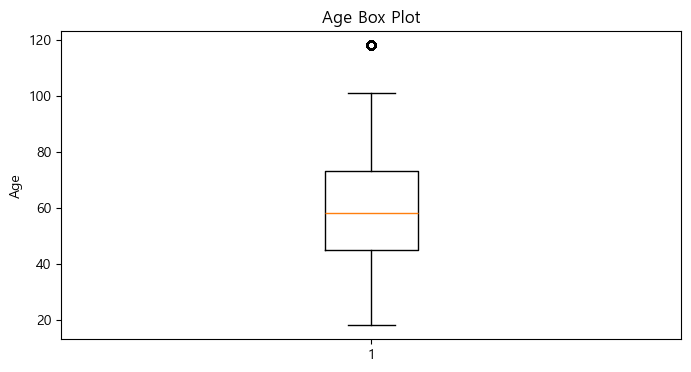

In [342]:
plt.figure(figsize=(8, 4))
plt.boxplot(df_profile['age'])
plt.title('Age Box Plot')
plt.ylabel('Age')
plt.show()

> Box Plot 확인 결과 age == 118 이 이상치로 두껍게 표시되어 있음  
> 실제 고객 나이가 118살이 아니라 별도 이상치 처리 해놨을 가능성 O

In [343]:
# age == 118인 데이터 수 확인
print((df_profile['age'] == 118).sum())

2175


> 앞에서 gender와 income 값이 없었던 2175건과 동일  
> 2175건이 고객 데이터 누락 행?

In [344]:
df_profile[df_profile['age'] == 118][['gender', 'income', 'income_missing']].head()

,gender,income,income_missing
0,Unknown,NaN,1
2,Unknown,NaN,1
4,Unknown,NaN,1
6,Unknown,NaN,1
7,Unknown,NaN,1


In [345]:
df_profile[df_profile['age'] == 118]['income'].isnull().sum()

np.int64(2175)

> age == 118인 값들을 결측치로 모두 바꾸고, age_missing 컬럼 생성해서 별도 관리

In [346]:
# income과 마찬가지로 age 값을 결측치로 놔두기
df_profile['age'] = df_profile['age'].replace(118, np.nan)
df_profile['age_missing'] = df_profile['age'].isna().astype(int)

In [347]:
df_profile.info()

<class 'pandas.DataFrame'>
RangeIndex: 17000 entries, 0 to 16999
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   gender            17000 non-null  category      
 1   age               14825 non-null  float64       
 2   id                17000 non-null  str           
 3   became_member_on  17000 non-null  datetime64[us]
 4   income            14825 non-null  float64       
 5   income_missing    17000 non-null  int64         
 6   age_missing       17000 non-null  int64         
dtypes: category(1), datetime64[us](1), float64(2), int64(2), str(1)
memory usage: 813.6 KB


In [348]:
df_profile.isna().sum()

gender                 0
age                 2175
id                     0
became_member_on       0
income              2175
income_missing         0
age_missing            0
dtype: int64

### 딕셔너리 & 리스트 형태 분리

#### transcript

In [349]:
# value 컬럼
# {'offer id': '9b98b8c7a33c4b65b9aebfe6a799e6d9'}
# {'amount': 21.35}
# {'offer_id': 'fafdcd668e3743c1bb461111dcafc2a4', 'reward': 2}

In [350]:
# ast(Abstract Syntax Tree): 문자열로 적혀 있는 파이썬 자료형을 실제 자료형으로 바꿔주는 파이썬 내장 모듈
# ast.literal_eval("[1, 2, 3]")      리스트
# ast.literal_eval("{'x': 10}")      딕셔너리
# ast.literal_eval("(1, 2)")         튜플
# ast.literal_eval("123")            숫자
# ast.literal_eval("'hello'")        문자열

In [351]:
import ast
import pandas as pd

# value 문자열 -> dict 변환
df_transcript['value_dict'] = df_transcript['value'].apply(ast.literal_eval)

# 필요한 값 추출
df_transcript['offer_id'] = df_transcript['value_dict'].apply(
    lambda x: x.get('offer id') if 'offer id' in x else x.get('offer_id')
)
df_transcript['amount'] = df_transcript['value_dict'].apply(lambda x: x.get('amount'))
df_transcript['reward'] = df_transcript['value_dict'].apply(lambda x: x.get('reward'))

# 숫자형 변환
df_transcript['amount'] = pd.to_numeric(df_transcript['amount'], errors='coerce')
df_transcript['reward'] = pd.to_numeric(df_transcript['reward'], errors='coerce').astype('Int64')

# 결과 확인
print(df_transcript[['event', 'offer_id', 'amount', 'reward']].tail(10))

                  event                          offer_id  amount  reward
306127      transaction                               NaN   25.14    <NA>
306128      transaction                               NaN   43.58    <NA>
306129      transaction                               NaN   22.64    <NA>
306130  offer completed  fafdcd668e3743c1bb461111dcafc2a4     NaN       2
306131      transaction                               NaN    2.20    <NA>
306132      transaction                               NaN    1.59    <NA>
306133      transaction                               NaN    9.53    <NA>
306134      transaction                               NaN    3.61    <NA>
306135      transaction                               NaN    3.53    <NA>
306136      transaction                               NaN    4.05    <NA>


In [352]:
df_transcript.info()

<class 'pandas.DataFrame'>
RangeIndex: 306137 entries, 0 to 306136
Data columns (total 8 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   person      306137 non-null  str    
 1   event       306137 non-null  str    
 2   value       306137 non-null  str    
 3   time        306137 non-null  int64  
 4   value_dict  306137 non-null  object 
 5   offer_id    167184 non-null  str    
 6   amount      138953 non-null  float64
 7   reward      33182 non-null   Int64  
dtypes: Int64(1), float64(1), int64(1), object(1), str(4)
memory usage: 19.0+ MB


In [353]:
# 결과 확인
print(df_transcript[['event', 'offer_id', 'amount', 'reward']].head(10))

            event                          offer_id  amount  reward
0  offer received  9b98b8c7a33c4b65b9aebfe6a799e6d9     NaN    <NA>
1  offer received  0b1e1539f2cc45b7b9fa7c272da2e1d7     NaN    <NA>
2  offer received  2906b810c7d4411798c6938adc9daaa5     NaN    <NA>
3  offer received  fafdcd668e3743c1bb461111dcafc2a4     NaN    <NA>
4  offer received  4d5c57ea9a6940dd891ad53e9dbe8da0     NaN    <NA>
5  offer received  f19421c1d4aa40978ebb69ca19b0e20d     NaN    <NA>
6  offer received  2298d6c36e964ae4a3e7e9706d1fb8c2     NaN    <NA>
7  offer received  3f207df678b143eea3cee63160fa8bed     NaN    <NA>
8  offer received  0b1e1539f2cc45b7b9fa7c272da2e1d7     NaN    <NA>
9  offer received  0b1e1539f2cc45b7b9fa7c272da2e1d7     NaN    <NA>


## 파생 컬럼

### portfolio

In [354]:
df_portfolio.info()

<class 'pandas.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   reward      10 non-null     int64
 1   channels    10 non-null     str  
 2   difficulty  10 non-null     int64
 3   duration    10 non-null     int64
 4   offer_type  10 non-null     str  
 5   id          10 non-null     str  
dtypes: int64(3), str(3)
memory usage: 612.0 bytes


#### channels 컬럼 분리

In [355]:
df_portfolio['channels'].value_counts()

channels
['web', 'email', 'mobile', 'social']    4
['web', 'email', 'mobile']              3
['email', 'mobile', 'social']           2
['web', 'email']                        1
Name: count, dtype: int64

In [356]:
# ['web', 'email', 'mobile', 'social'] >> 어떻게 나눠서 각각의 컬럼을 만들고 1, 0으로 할 수 있을까?
df_portfolio['channels'] = df_portfolio['channels'].apply(ast.literal_eval)
        
for ch in ['web', 'email', 'mobile', 'social']:
    df_portfolio[ch] = df_portfolio['channels'].apply(lambda x: 1 if ch in x else 0)

In [357]:
df_portfolio.head()

,reward,channels,difficulty,duration,offer_type,id,web,email,mobile,social
0,10,"[email, mobile, social]",10,7,bogo,ae264e3637204a6fb9bb56bc8210ddfd,0,1,1,1
1,10,"[web, email, mobile, social]",10,5,bogo,4d5c57ea9a6940dd891ad53e9dbe8da0,1,1,1,1
2,0,"[web, email, mobile]",0,4,informational,3f207df678b143eea3cee63160fa8bed,1,1,1,0
3,5,"[web, email, mobile]",5,7,bogo,9b98b8c7a33c4b65b9aebfe6a799e6d9,1,1,1,0
4,5,"[web, email]",20,10,discount,0b1e1539f2cc45b7b9fa7c272da2e1d7,1,1,0,0


In [358]:
df_portfolio.info()

<class 'pandas.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   reward      10 non-null     int64 
 1   channels    10 non-null     object
 2   difficulty  10 non-null     int64 
 3   duration    10 non-null     int64 
 4   offer_type  10 non-null     str   
 5   id          10 non-null     str   
 6   web         10 non-null     int64 
 7   email       10 non-null     int64 
 8   mobile      10 non-null     int64 
 9   social      10 non-null     int64 
dtypes: int64(7), object(1), str(2)
memory usage: 932.0+ bytes


#### offer_type & id 병합 파생컬럼

In [359]:
# offer_label = offer_type + '_' + 순서
# ex) bogo_1, informational_1, discount_1
df_portfolio['offer_label'] = (
    df_portfolio['offer_type']
    + '_'
    + (df_portfolio.groupby('offer_type').cumcount() + 1).astype(str)
)

df_portfolio['offer_label'].unique()

<StringArray>
[         'bogo_1',          'bogo_2', 'informational_1',          'bogo_3',
      'discount_1',      'discount_2',      'discount_3', 'informational_2',
          'bogo_4',      'discount_4']
Length: 10, dtype: str

In [360]:
# offer_type 컬럼 범주형 변환
df_portfolio['offer_type'] = df_portfolio['offer_type'].astype('category')

### profile

> 앞에서 이미 완료  
> age_missing, income_missing 파생컬럼 생성

### transcript

In [361]:
df_transcript['event'].unique()

<StringArray>
['offer received', 'offer viewed', 'transaction', 'offer completed']
Length: 4, dtype: str

In [362]:
df_transcript['event'] = (
    df_transcript['event']
    .replace({
        'offer received': 'received',
        'offer viewed': 'viewed',
        'offer completed': 'completed'
    })
)

In [363]:
# event 컬럼 범주형 변환
df_transcript['event'] = df_transcript['event'].astype('category')

In [364]:
df_transcript['event'].unique()

['received', 'viewed', 'transaction', 'completed']
Categories (4, str): ['completed', 'received', 'transaction', 'viewed']

In [365]:
df_transcript.info()

<class 'pandas.DataFrame'>
RangeIndex: 306137 entries, 0 to 306136
Data columns (total 8 columns):
 #   Column      Non-Null Count   Dtype   
---  ------      --------------   -----   
 0   person      306137 non-null  str     
 1   event       306137 non-null  category
 2   value       306137 non-null  str     
 3   time        306137 non-null  int64   
 4   value_dict  306137 non-null  object  
 5   offer_id    167184 non-null  str     
 6   amount      138953 non-null  float64 
 7   reward      33182 non-null   Int64   
dtypes: Int64(1), category(1), float64(1), int64(1), object(1), str(3)
memory usage: 16.9+ MB


In [366]:
# time 컬럼: 현재 시간 기준 → 일(24시간) 기준 파생컬럼(time_days) 생성
# 0~23시간 = 1일차, 24~47시간 = 2일차

df_transcript['time_days'] = (df_transcript['time'] // 24) + 1

df_transcript['time_days'].tail(50)

306087    30
306088    30
306089    30
306090    30
306091    30
306092    30
306093    30
306094    30
306095    30
306096    30
306097    30
306098    30
306099    30
306100    30
306101    30
306102    30
306103    30
306104    30
306105    30
306106    30
306107    30
306108    30
306109    30
306110    30
306111    30
306112    30
306113    30
306114    30
306115    30
306116    30
306117    30
306118    30
306119    30
306120    30
306121    30
306122    30
306123    30
306124    30
306125    30
306126    30
306127    30
306128    30
306129    30
306130    30
306131    30
306132    30
306133    30
306134    30
306135    30
306136    30
Name: time_days, dtype: int64

In [367]:
df_transcript['time_days'].unique()

array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
       18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30])

> offer_received 기준으로 30일차까지 데이터!

## 테이블 merge

### portfolio

In [368]:
df_portfolio.info()

<class 'pandas.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   reward       10 non-null     int64   
 1   channels     10 non-null     object  
 2   difficulty   10 non-null     int64   
 3   duration     10 non-null     int64   
 4   offer_type   10 non-null     category
 5   id           10 non-null     str     
 6   web          10 non-null     int64   
 7   email        10 non-null     int64   
 8   mobile       10 non-null     int64   
 9   social       10 non-null     int64   
 10  offer_label  10 non-null     str     
dtypes: category(1), int64(7), object(1), str(2)
memory usage: 966.0+ bytes


> 제거 컬럼  
> - channels
> - offer_type

#### 컬럼 제거 진행

In [369]:
df_portfolio = df_portfolio.drop(columns=['offer_type', 'channels'])

In [370]:
df_portfolio.info()

<class 'pandas.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   reward       10 non-null     int64
 1   difficulty   10 non-null     int64
 2   duration     10 non-null     int64
 3   id           10 non-null     str  
 4   web          10 non-null     int64
 5   email        10 non-null     int64
 6   mobile       10 non-null     int64
 7   social       10 non-null     int64
 8   offer_label  10 non-null     str  
dtypes: int64(7), str(2)
memory usage: 852.0 bytes


In [371]:
df_portfolio.shape

(10, 9)

### profile

In [372]:
df_profile.info()

<class 'pandas.DataFrame'>
RangeIndex: 17000 entries, 0 to 16999
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   gender            17000 non-null  category      
 1   age               14825 non-null  float64       
 2   id                17000 non-null  str           
 3   became_member_on  17000 non-null  datetime64[us]
 4   income            14825 non-null  float64       
 5   income_missing    17000 non-null  int64         
 6   age_missing       17000 non-null  int64         
dtypes: category(1), datetime64[us](1), float64(2), int64(2), str(1)
memory usage: 813.6 KB


> 컬럼명 변경(portfolio의 id와 헷갈릴 우려가 있음)  
> id → customer_id

#### id 컬럼명 변경

In [373]:
df_profile = df_profile.rename(columns={'id': 'customer_id'})

In [374]:
df_profile.info()

<class 'pandas.DataFrame'>
RangeIndex: 17000 entries, 0 to 16999
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   gender            17000 non-null  category      
 1   age               14825 non-null  float64       
 2   customer_id       17000 non-null  str           
 3   became_member_on  17000 non-null  datetime64[us]
 4   income            14825 non-null  float64       
 5   income_missing    17000 non-null  int64         
 6   age_missing       17000 non-null  int64         
dtypes: category(1), datetime64[us](1), float64(2), int64(2), str(1)
memory usage: 813.6 KB


In [375]:
df_profile.shape

(17000, 7)

### transcript

In [376]:
df_transcript.info()

<class 'pandas.DataFrame'>
RangeIndex: 306137 entries, 0 to 306136
Data columns (total 9 columns):
 #   Column      Non-Null Count   Dtype   
---  ------      --------------   -----   
 0   person      306137 non-null  str     
 1   event       306137 non-null  category
 2   value       306137 non-null  str     
 3   time        306137 non-null  int64   
 4   value_dict  306137 non-null  object  
 5   offer_id    167184 non-null  str     
 6   amount      138953 non-null  float64 
 7   reward      33182 non-null   Int64   
 8   time_days   306137 non-null  int64   
dtypes: Int64(1), category(1), float64(1), int64(2), object(1), str(3)
memory usage: 19.3+ MB


> 제거 컬럼
> - value
> - value_dict

> 컬럼명 변경(portfolio의 reward와 헷갈릴 우려가 있음)  
> reward → bonus_reward

#### 컬럼 제거

In [377]:
df_transcript = df_transcript.drop(columns=['value', 'value_dict'])

#### 컬럼명 변경

In [378]:
df_transcript = df_transcript.rename(columns={'reward': 'bonus_reward'})

In [379]:
df_transcript.info()

<class 'pandas.DataFrame'>
RangeIndex: 306137 entries, 0 to 306136
Data columns (total 7 columns):
 #   Column        Non-Null Count   Dtype   
---  ------        --------------   -----   
 0   person        306137 non-null  str     
 1   event         306137 non-null  category
 2   time          306137 non-null  int64   
 3   offer_id      167184 non-null  str     
 4   amount        138953 non-null  float64 
 5   bonus_reward  33182 non-null   Int64   
 6   time_days     306137 non-null  int64   
dtypes: Int64(1), category(1), float64(1), int64(2), str(2)
memory usage: 14.6 MB


In [380]:
df_transcript.shape

(306137, 7)

> merge 해서 offer_id 연결해주고 offer_label 붙여주기

### merge 진행

In [381]:
# 통합(merge)
df_merge = df_transcript.merge(df_profile, left_on='person', right_on='customer_id', how='left') \
                        .merge(df_portfolio, left_on='offer_id', right_on='id', how='left')

df_merge.info()

<class 'pandas.DataFrame'>
RangeIndex: 306137 entries, 0 to 306136
Data columns (total 23 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   person            306137 non-null  str           
 1   event             306137 non-null  category      
 2   time              306137 non-null  int64         
 3   offer_id          167184 non-null  str           
 4   amount            138953 non-null  float64       
 5   bonus_reward      33182 non-null   Int64         
 6   time_days         306137 non-null  int64         
 7   gender            306137 non-null  category      
 8   age               272388 non-null  float64       
 9   customer_id       306137 non-null  str           
 10  became_member_on  306137 non-null  datetime64[us]
 11  income            272388 non-null  float64       
 12  income_missing    306137 non-null  int64         
 13  age_missing       306137 non-null  int64         
 14  reward         

In [382]:
df_merge.head(20)

,person,event,time,offer_id,amount,bonus_reward,time_days,gender,age,customer_id,became_member_on,income,income_missing,age_missing,reward,difficulty,duration,id,web,email,mobile,social,offer_label
0,78afa995795e4d85b5d9ceeca43f5fef,received,0,9b98b8c7a33c4b65b9aebfe6a799e6d9,NaN,<NA>,1,F,75.0,78afa995795e4d85b5d9ceeca43f5fef,2017-05-09,100000.0,0,0,5.0,5.0,7.0,9b98b8c7a33c4b65b9aebfe6a799e6d9,1.0,1.0,1.0,0.0,bogo_3
1,a03223e636434f42ac4c3df47e8bac43,received,0,0b1e1539f2cc45b7b9fa7c272da2e1d7,NaN,<NA>,1,Unknown,NaN,a03223e636434f42ac4c3df47e8bac43,2017-08-04,NaN,1,1,5.0,20.0,10.0,0b1e1539f2cc45b7b9fa7c272da2e1d7,1.0,1.0,0.0,0.0,discount_1
2,e2127556f4f64592b11af22de27a7932,received,0,2906b810c7d4411798c6938adc9daaa5,NaN,<NA>,1,M,68.0,e2127556f4f64592b11af22de27a7932,2018-04-26,70000.0,0,0,2.0,10.0,7.0,2906b810c7d4411798c6938adc9daaa5,1.0,1.0,1.0,0.0,discount_4
3,8ec6ce2a7e7949b1bf142def7d0e0586,received,0,fafdcd668e3743c1bb461111dcafc2a4,NaN,<NA>,1,Unknown,NaN,8ec6ce2a7e7949b1bf142def7d0e0586,2017-09-25,NaN,1,1,2.0,10.0,10.0,fafdcd668e3743c1bb461111dcafc2a4,1.0,1.0,1.0,1.0,discount_3
4,68617ca6246f4fbc85e91a2a49552598,received,0,4d5c57ea9a6940dd891ad53e9dbe8da0,NaN,<NA>,1,Unknown,NaN,68617ca6246f4fbc85e91a2a49552598,2017-10-02,NaN,1,1,10.0,10.0,5.0,4d5c57ea9a6940dd891ad53e9dbe8da0,1.0,1.0,1.0,1.0,bogo_2
5,389bc3fa690240e798340f5a15918d5c,received,0,f19421c1d4aa40978ebb69ca19b0e20d,NaN,<NA>,1,M,65.0,389bc3fa690240e798340f5a15918d5c,2018-02-09,53000.0,0,0,5.0,5.0,5.0,f19421c1d4aa40978ebb69ca19b0e20d,1.0,1.0,1.0,1.0,bogo_4
6,c4863c7985cf408faee930f111475da3,received,0,2298d6c36e964ae4a3e7e9706d1fb8c2,NaN,<NA>,1,Unknown,NaN,c4863c7985cf408faee930f111475da3,2017-08-24,NaN,1,1,3.0,7.0,7.0,2298d6c36e964ae4a3e7e9706d1fb8c2,1.0,1.0,1.0,1.0,discount_2
7,2eeac8d8feae4a8cad5a6af0499a211d,received,0,3f207df678b143eea3cee63160fa8bed,NaN,<NA>,1,M,58.0,2eeac8d8feae4a8cad5a6af0499a211d,2017-11-11,51000.0,0,0,0.0,0.0,4.0,3f207df678b143eea3cee63160fa8bed,1.0,1.0,1.0,0.0,informational_1
8,aa4862eba776480b8bb9c68455b8c2e1,received,0,0b1e1539f2cc45b7b9fa7c272da2e1d7,NaN,<NA>,1,F,61.0,aa4862eba776480b8bb9c68455b8c2e1,2017-09-11,57000.0,0,0,5.0,20.0,10.0,0b1e1539f2cc45b7b9fa7c272da2e1d7,1.0,1.0,0.0,0.0,discount_1
9,31dda685af34476cad5bc968bdb01c53,received,0,0b1e1539f2cc45b7b9fa7c272da2e1d7,NaN,<NA>,1,F,62.0,31dda685af34476cad5bc968bdb01c53,2016-02-11,71000.0,0,0,5.0,20.0,10.0,0b1e1539f2cc45b7b9fa7c272da2e1d7,1.0,1.0,0.0,0.0,discount_1


> 테이블 merge 완료되어 기존 transcript 테이블의 id 컬럼은 삭제 진행

In [383]:
# transcript 테이블 id 컬럼 삭제
df_merge = df_merge.drop(columns='id')

In [384]:
# ============================================================
# 오퍼 수신 건 기준 정상/이상 순서 라벨링 컬럼 생성
#   True  : 정상 순서 (received -> viewed -> completed)
#   False : 이상 순서 (received -> completed -> viewed)
#   <NA>  : viewed 또는 completed가 없어 순서 판정 불가
# ============================================================

# 같은 time일 때 이벤트 순서를 고정하기 위한 보조 컬럼 생성
event_order_map = {
    'received': 0,
    'viewed': 1,
    'completed': 2,
    'transaction': 3
}

df_merge['event_order'] = df_merge['event'].map(event_order_map).fillna(99)

# 고객-오퍼 기준으로 시간 순 정렬
df_merge = df_merge.sort_values(
    by=['person', 'offer_id', 'time', 'event_order'],
    ascending=[True, True, True, True]
).reset_index(drop=True)

# 같은 고객 + 같은 오퍼 안에서 received가 나올 때마다 수신 순번 생성
df_merge['is_received'] = (df_merge['event'] == 'received').astype(int)

df_merge['receive_seq'] = (
    df_merge.groupby(['person', 'offer_id'])['is_received']
            .cumsum()
)

# 각 수신 건별 최초 viewed / 최초 completed 시간 추출
viewed_summary = (
    df_merge[(df_merge['event'] == 'viewed') & (df_merge['receive_seq'] > 0)]
    .groupby(['person', 'offer_id', 'receive_seq'], as_index=False)
    .agg(first_viewed_time=('time', 'min'))
)

completed_summary = (
    df_merge[(df_merge['event'] == 'completed') & (df_merge['receive_seq'] > 0)]
    .groupby(['person', 'offer_id', 'receive_seq'], as_index=False)
    .agg(first_completed_time=('time', 'min'))
)

# 수신 건 단위 테이블 생성
receive_order_base = (
    df_merge[(df_merge['event'] == 'received') & (df_merge['receive_seq'] > 0)]
    [['person', 'offer_id', 'receive_seq']]
    .drop_duplicates()
    .merge(viewed_summary, on=['person', 'offer_id', 'receive_seq'], how='left')
    .merge(completed_summary, on=['person', 'offer_id', 'receive_seq'], how='left')
)

# 정상/이상 순서 라벨 생성
#    True  = 정상 순서 (received -> viewed -> completed)
#    False = 이상 순서 (received -> completed -> viewed)
#    <NA>  = viewed 또는 completed가 없어 판정 불가
receive_order_base['order_label'] = pd.Series(
    np.where(
        receive_order_base['first_viewed_time'].notna() &
        receive_order_base['first_completed_time'].notna(),
        receive_order_base['first_viewed_time'] <= receive_order_base['first_completed_time'],
        pd.NA
    ),
    dtype='boolean'
)

# 원본 df_merge에 라벨 붙이기
df_merge = df_merge.merge(
    receive_order_base[['person', 'offer_id', 'receive_seq', 'order_label']],
    on=['person', 'offer_id', 'receive_seq'],
    how='left'
)

# 확인
print("=" * 60)
print("order_label 생성 완료")
print("=" * 60)
print(df_merge['order_label'].value_counts(dropna=False))

# 필요하면 수신 건 기준 분포도 같이 확인
print("\n[수신 건 기준 분포]")
print(receive_order_base['order_label'].value_counts(dropna=False))

order_label 생성 완료
order_label
<NA>     228496
True      68101
False      9540
Name: count, dtype: Int64

[수신 건 기준 분포]
order_label
<NA>     50505
True     22608
False     3164
Name: count, dtype: Int64


In [385]:
# 데이터 추출
df_merge.to_csv('../../Data/merged_df_260325.csv', index=False)

In [386]:
df_merge.info()

<class 'pandas.DataFrame'>
RangeIndex: 306137 entries, 0 to 306136
Data columns (total 26 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   person            306137 non-null  str           
 1   event             306137 non-null  category      
 2   time              306137 non-null  int64         
 3   offer_id          167184 non-null  str           
 4   amount            138953 non-null  float64       
 5   bonus_reward      33182 non-null   Int64         
 6   time_days         306137 non-null  int64         
 7   gender            306137 non-null  category      
 8   age               272388 non-null  float64       
 9   customer_id       306137 non-null  str           
 10  became_member_on  306137 non-null  datetime64[us]
 11  income            272388 non-null  float64       
 12  income_missing    306137 non-null  int64         
 13  age_missing       306137 non-null  int64         
 14  reward         

In [387]:
df_merge.shape

(306137, 26)

In [388]:
df_merge.tail(10)

,person,event,time,offer_id,amount,bonus_reward,time_days,gender,age,customer_id,became_member_on,income,income_missing,age_missing,reward,difficulty,duration,web,email,mobile,social,offer_label,event_order,is_received,receive_seq,order_label
306127,ffff82501cea40309d5fdd7edcca4a07,transaction,234,NaN,18.08,<NA>,10,F,45.0,ffff82501cea40309d5fdd7edcca4a07,2016-11-25,62000.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3,0,NaN,<NA>
306128,ffff82501cea40309d5fdd7edcca4a07,transaction,264,NaN,23.32,<NA>,12,F,45.0,ffff82501cea40309d5fdd7edcca4a07,2016-11-25,62000.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3,0,NaN,<NA>
306129,ffff82501cea40309d5fdd7edcca4a07,transaction,312,NaN,16.86,<NA>,14,F,45.0,ffff82501cea40309d5fdd7edcca4a07,2016-11-25,62000.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3,0,NaN,<NA>
306130,ffff82501cea40309d5fdd7edcca4a07,transaction,384,NaN,15.57,<NA>,17,F,45.0,ffff82501cea40309d5fdd7edcca4a07,2016-11-25,62000.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3,0,NaN,<NA>
306131,ffff82501cea40309d5fdd7edcca4a07,transaction,414,NaN,17.55,<NA>,18,F,45.0,ffff82501cea40309d5fdd7edcca4a07,2016-11-25,62000.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3,0,NaN,<NA>
306132,ffff82501cea40309d5fdd7edcca4a07,transaction,498,NaN,13.17,<NA>,21,F,45.0,ffff82501cea40309d5fdd7edcca4a07,2016-11-25,62000.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3,0,NaN,<NA>
306133,ffff82501cea40309d5fdd7edcca4a07,transaction,504,NaN,7.79,<NA>,22,F,45.0,ffff82501cea40309d5fdd7edcca4a07,2016-11-25,62000.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3,0,NaN,<NA>
306134,ffff82501cea40309d5fdd7edcca4a07,transaction,576,NaN,14.23,<NA>,25,F,45.0,ffff82501cea40309d5fdd7edcca4a07,2016-11-25,62000.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3,0,NaN,<NA>
306135,ffff82501cea40309d5fdd7edcca4a07,transaction,606,NaN,10.12,<NA>,26,F,45.0,ffff82501cea40309d5fdd7edcca4a07,2016-11-25,62000.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3,0,NaN,<NA>
306136,ffff82501cea40309d5fdd7edcca4a07,transaction,648,NaN,18.91,<NA>,28,F,45.0,ffff82501cea40309d5fdd7edcca4a07,2016-11-25,62000.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3,0,NaN,<NA>


### df_merge 검증

In [389]:
# ============================================================
# [검증용]
# merged_df 기준으로 같은 수신 건(receive_seq) 안에서
# viewed가 여러 번 발생했는지 확인
# - 삭제는 하지 않음
# - received 기준 문맥까지 반영한 검증
# ============================================================

# 1. 작업용 복사본 생성
view_check_df = df_merge.copy()

# 2. 이벤트 순서 보조 컬럼
event_order_map = {
    'received': 0,
    'viewed': 1,
    'completed': 2,
    'transaction': 3
}

view_check_df['event_order'] = view_check_df['event'].map(event_order_map).fillna(99)

# 3. 고객-오퍼 기준 시간 순 정렬
view_check_df = view_check_df.sort_values(
    by=['person', 'offer_id', 'time', 'event_order'],
    ascending=[True, True, True, True]
).reset_index(drop=True)

# 4. received 기준 수신 순번(receive_seq) 생성
view_check_df['is_received'] = (view_check_df['event'] == 'received').astype(int)

view_check_df['receive_seq'] = (
    view_check_df.groupby(['person', 'offer_id'])['is_received']
                 .cumsum()
)

# 5. 같은 수신 건 안에서 viewed 개수 집계
viewed_per_receive = (
    view_check_df[
        (view_check_df['event'] == 'viewed') &
        (view_check_df['receive_seq'] > 0)
    ]
    .groupby(['person', 'offer_id', 'receive_seq'], as_index=False)
    .size()
    .rename(columns={'size': 'viewed_count'})
)

# 6. viewed가 2건 이상인 수신 건만 추출
multi_viewed_receive = viewed_per_receive[viewed_per_receive['viewed_count'] > 1].copy()

print("=" * 60)
print("같은 수신 건 안에서 viewed 2건 이상 발생 여부 검증")
print("=" * 60)
print(f"전체 viewed 수신 건 수: {len(viewed_per_receive):,}")
print(f"viewed가 2건 이상인 수신 건 수: {len(multi_viewed_receive):,}")
print()

if len(multi_viewed_receive) > 0:
    print("[문제 후보 수신 건 예시 20개]")
    display(multi_viewed_receive.head(20))

    # 문제 후보의 원본 이벤트 로그도 같이 확인
    sample_keys = multi_viewed_receive.head(5)[['person', 'offer_id', 'receive_seq']]

    sample_logs = view_check_df.merge(
        sample_keys,
        on=['person', 'offer_id', 'receive_seq'],
        how='inner'
    ).sort_values(['person', 'offer_id', 'receive_seq', 'time', 'event_order'])

    print("\n[문제 후보 원본 로그 예시]")
    display(sample_logs[['person', 'offer_id', 'receive_seq', 'event', 'time']].head(50))
else:
    print("같은 수신 건 안에서 viewed가 여러 번 발생한 케이스는 없습니다.")

같은 수신 건 안에서 viewed 2건 이상 발생 여부 검증
전체 viewed 수신 건 수: 57,725
viewed가 2건 이상인 수신 건 수: 0

같은 수신 건 안에서 viewed가 여러 번 발생한 케이스는 없습니다.


In [390]:
# ============================================================
# [검증용]
# 같은 수신 건(receive_seq) 안에서
# received -> completed -> viewed 이상 순서가 있는지 확인
# - 삭제는 하지 않음
# - 수신 건 단위로 정상/이상 순서만 검증
# ============================================================


# 1. 작업용 복사본 생성
order_check_df = df_merge.copy()

# 2. 같은 time일 때 이벤트 순서 고정
#    received -> viewed -> completed -> transaction
event_order_map = {
    'received': 0,
    'viewed': 1,
    'completed': 2,
    'transaction': 3
}

order_check_df['event_order'] = order_check_df['event'].map(event_order_map).fillna(99)

# 3. 고객-오퍼 기준 시간 순 정렬
order_check_df = order_check_df.sort_values(
    by=['person', 'offer_id', 'time', 'event_order'],
    ascending=[True, True, True, True]
).reset_index(drop=True)

# 4. received 기준 수신 순번(receive_seq) 생성
order_check_df['is_received'] = (order_check_df['event'] == 'received').astype(int)

order_check_df['receive_seq'] = (
    order_check_df.groupby(['person', 'offer_id'])['is_received']
                  .cumsum()
)

# 5. 각 수신 건별 최초 viewed / 최초 completed 시간 추출
viewed_summary = (
    order_check_df[
        (order_check_df['event'] == 'viewed') &
        (order_check_df['receive_seq'] > 0)
    ]
    .groupby(['person', 'offer_id', 'receive_seq'], as_index=False)
    .agg(first_viewed_time=('time', 'min'))
)

completed_summary = (
    order_check_df[
        (order_check_df['event'] == 'completed') &
        (order_check_df['receive_seq'] > 0)
    ]
    .groupby(['person', 'offer_id', 'receive_seq'], as_index=False)
    .agg(first_completed_time=('time', 'min'))
)

# 6. 수신 건 기준 base 생성
receive_order_base = (
    order_check_df[
        (order_check_df['event'] == 'received') &
        (order_check_df['receive_seq'] > 0)
    ]
    [['person', 'offer_id', 'receive_seq']]
    .drop_duplicates()
    .merge(viewed_summary, on=['person', 'offer_id', 'receive_seq'], how='left')
    .merge(completed_summary, on=['person', 'offer_id', 'receive_seq'], how='left')
)

# 7. 순서 라벨 생성
#    True  = 정상 순서 (viewed <= completed)
#    False = 이상 순서 (completed < viewed)
#    <NA>  = viewed 또는 completed가 없어 판정 불가
receive_order_base['order_label'] = pd.Series(
    np.where(
        receive_order_base['first_viewed_time'].notna() &
        receive_order_base['first_completed_time'].notna(),
        receive_order_base['first_viewed_time'] <= receive_order_base['first_completed_time'],
        pd.NA
    ),
    dtype='boolean'
)

# 8. 결과 요약
print("=" * 60)
print("수신 건 기준 정상/이상 순서 검증")
print("=" * 60)
print(receive_order_base['order_label'].value_counts(dropna=False))
print()

normal_cnt = (receive_order_base['order_label'] == True).sum()
abnormal_cnt = (receive_order_base['order_label'] == False).sum()
na_cnt = receive_order_base['order_label'].isna().sum()

print(f"정상 순서(True) 수신 건 수 : {normal_cnt:,}")
print(f"이상 순서(False) 수신 건 수 : {abnormal_cnt:,}")
print(f"판정 불가(<NA>) 수신 건 수  : {na_cnt:,}")

# 9. 이상 순서 케이스만 따로 보기
abnormal_cases = receive_order_base[receive_order_base['order_label'] == False].copy()

print("\n" + "=" * 60)
print("이상 순서(received -> completed -> viewed) 케이스 수")
print("=" * 60)
print(f"{len(abnormal_cases):,}")

if len(abnormal_cases) > 0:
    print("\n[이상 순서 예시 20건]")
    display(abnormal_cases.head(20))

    # 10. 이상 순서 원본 이벤트 로그 예시 확인
    sample_keys = abnormal_cases.head(5)[['person', 'offer_id', 'receive_seq']]

    abnormal_logs = order_check_df.merge(
        sample_keys,
        on=['person', 'offer_id', 'receive_seq'],
        how='inner'
    ).sort_values(['person', 'offer_id', 'receive_seq', 'time', 'event_order'])

    print("\n[이상 순서 원본 로그 예시]")
    display(
        abnormal_logs[
            ['person', 'offer_id', 'receive_seq', 'event', 'time']
        ].head(50)
    )
else:
    print("이상 순서 케이스는 없습니다.")

수신 건 기준 정상/이상 순서 검증
order_label
<NA>     50505
True     22608
False     3164
Name: count, dtype: Int64

정상 순서(True) 수신 건 수 : 22,608
이상 순서(False) 수신 건 수 : 3,164
판정 불가(<NA>) 수신 건 수  : 50,505

이상 순서(received -> completed -> viewed) 케이스 수
3,164

[이상 순서 예시 20건]


,person,offer_id,receive_seq,first_viewed_time,first_completed_time,order_label
3,0009655768c64bdeb2e877511632db8f,f19421c1d4aa40978ebb69ca19b0e20d,1.0,456.0,414.0,False
4,0009655768c64bdeb2e877511632db8f,fafdcd668e3743c1bb461111dcafc2a4,1.0,540.0,528.0,False
57,00715b6e55c3431cb56ff7307eb19675,0b1e1539f2cc45b7b9fa7c272da2e1d7,1.0,228.0,210.0,False
59,00715b6e55c3431cb56ff7307eb19675,2906b810c7d4411798c6938adc9daaa5,1.0,564.0,534.0,False
62,00715b6e55c3431cb56ff7307eb19675,ae264e3637204a6fb9bb56bc8210ddfd,1.0,36.0,12.0,False
136,00b3c376db2a4115af3aef34a02f61d6,4d5c57ea9a6940dd891ad53e9dbe8da0,1.0,594.0,582.0,False
148,00bbce6533f44ddeaf4dd32bcab55441,fafdcd668e3743c1bb461111dcafc2a4,1.0,630.0,600.0,False
159,00c20a9202d5475190b31a24de6fb06d,2298d6c36e964ae4a3e7e9706d1fb8c2,1.0,354.0,348.0,False
165,00c2f812f4604c8893152a5c6572030e,4d5c57ea9a6940dd891ad53e9dbe8da0,3.0,600.0,582.0,False
166,00c2f812f4604c8893152a5c6572030e,fafdcd668e3743c1bb461111dcafc2a4,1.0,444.0,414.0,False



[이상 순서 원본 로그 예시]


,person,offer_id,receive_seq,event,time
0,0009655768c64bdeb2e877511632db8f,f19421c1d4aa40978ebb69ca19b0e20d,1.0,received,408
1,0009655768c64bdeb2e877511632db8f,f19421c1d4aa40978ebb69ca19b0e20d,1.0,completed,414
2,0009655768c64bdeb2e877511632db8f,f19421c1d4aa40978ebb69ca19b0e20d,1.0,viewed,456
3,0009655768c64bdeb2e877511632db8f,fafdcd668e3743c1bb461111dcafc2a4,1.0,received,504
4,0009655768c64bdeb2e877511632db8f,fafdcd668e3743c1bb461111dcafc2a4,1.0,completed,528
5,0009655768c64bdeb2e877511632db8f,fafdcd668e3743c1bb461111dcafc2a4,1.0,viewed,540
6,00715b6e55c3431cb56ff7307eb19675,0b1e1539f2cc45b7b9fa7c272da2e1d7,1.0,received,168
7,00715b6e55c3431cb56ff7307eb19675,0b1e1539f2cc45b7b9fa7c272da2e1d7,1.0,completed,210
8,00715b6e55c3431cb56ff7307eb19675,0b1e1539f2cc45b7b9fa7c272da2e1d7,1.0,viewed,228
9,00715b6e55c3431cb56ff7307eb19675,2906b810c7d4411798c6938adc9daaa5,1.0,received,504


In [391]:
# ============================================================
# [검증용]
# order_label별 오퍼 유형 분포 확인
# ============================================================

order_offer_check = (
    df_merge[df_merge['event'] == 'received']
    [['person', 'offer_id', 'receive_seq', 'offer_label', 'order_label']]
    .drop_duplicates()
)

print("=" * 60)
print("order_label별 offer_label 분포")
print("=" * 60)

display(
    pd.crosstab(
        order_offer_check['offer_label'],
        order_offer_check['order_label'],
        dropna=False
    )
)

order_label별 offer_label 분포


order_label,False,True,<NA>
offer_label,,,
bogo_1,483,2513,4662
bogo_2,342,2625,4626
bogo_3,473,2055,5149
bogo_4,431,3366,3774
discount_1,216,1294,6158
discount_2,431,4228,2987
discount_3,359,4477,2761
discount_4,429,2050,5153
informational_1,0,0,7617


### transactions 생성

In [392]:
# ============================================================
# transactions 테이블 생성
# - transaction 1건 중심 테이블
# - reward offer 완료 이력 연결
# - txn_offer_type 생성
#   normal / bogo / discount / multi
# - informational은 여기서 범주화하지 않음
# ============================================================


# ------------------------------------------------------------
# 1. offer_label -> offer_family 변환
# ------------------------------------------------------------
def get_offer_family(label):
    if pd.isna(label):
        return np.nan
    label = str(label).lower()
    if 'bogo' in label:
        return 'bogo'
    elif 'discount' in label:
        return 'discount'
    elif 'informational' in label:
        return 'informational'
    else:
        return np.nan

df_work = df_merge.copy()
df_work['offer_family'] = df_work['offer_label'].apply(get_offer_family)

# ------------------------------------------------------------
# 2. transaction 원본 테이블 생성
#    - transaction 이벤트만 추출
#    - 동일 person/time/amount가 여러 건일 수 있으므로 tx_occurrence 부여
# ------------------------------------------------------------
transactions = (
    df_work[df_work['event'] == 'transaction']
    [
        [
            'person', 'customer_id', 'time', 'amount',
            'time_days', 'gender', 'age', 'became_member_on',
            'income', 'income_missing', 'age_missing'
        ]
    ]
    .copy()
)

transactions = transactions.sort_values(['person', 'time', 'amount']).reset_index(drop=True)

transactions['tx_occurrence'] = (
    transactions.groupby(['person', 'time', 'amount']).cumcount() + 1
)

transactions['tx_key'] = (
    transactions['person'].astype(str) + '|' +
    transactions['time'].astype(str) + '|' +
    transactions['amount'].astype(str) + '|' +
    transactions['tx_occurrence'].astype(str)
)

print("=" * 60)
print("transaction 원본 건수")
print("=" * 60)
print(len(transactions))

# ------------------------------------------------------------
# 3. reward offer 완료 이력 추출
#    - completed 이벤트 중 bogo / discount만 사용
# ------------------------------------------------------------
reward_completed = (
    df_work[
        (df_work['event'] == 'completed') &
        (df_work['offer_family'].isin(['bogo', 'discount']))
    ]
    [
        [
            'person', 'time', 'offer_id', 'offer_label', 'offer_family',
            'bonus_reward', 'reward', 'difficulty', 'duration',
            'web', 'email', 'mobile', 'social',
            'receive_seq', 'order_label'
        ]
    ]
    .copy()
)

reward_completed = reward_completed.sort_values(
    ['person', 'time', 'offer_family', 'offer_id']
).reset_index(drop=True)

print("\n" + "=" * 60)
print("reward completed 건수")
print("=" * 60)
print(len(reward_completed))

# ------------------------------------------------------------
# 4. transaction과 reward completed 연결
#    - 같은 person + 같은 time 기준 연결
# ------------------------------------------------------------
tx_reward = transactions.merge(
    reward_completed,
    on=['person', 'time'],
    how='left'
)

# ------------------------------------------------------------
# 5. 거래 건 기준 reward offer 요약
# ------------------------------------------------------------
tx_reward_summary = (
    tx_reward.groupby(['tx_key'], dropna=False)
    .agg(
        person=('person', 'first'),
        customer_id=('customer_id', 'first'),
        time=('time', 'first'),
        amount=('amount', 'first'),
        tx_occurrence=('tx_occurrence', 'first'),
        time_days=('time_days', 'first'),
        gender=('gender', 'first'),
        age=('age', 'first'),
        became_member_on=('became_member_on', 'first'),
        income=('income', 'first'),
        income_missing=('income_missing', 'first'),
        age_missing=('age_missing', 'first'),

        reward_offer_family_list=('offer_family', lambda x: sorted(set([v for v in x.dropna()]))),
        reward_offer_label_list=('offer_label', lambda x: sorted(set([v for v in x.dropna()]))),
        reward_offer_id_list=('offer_id', lambda x: sorted(set([v for v in x.dropna()]))),

        linked_reward_offer_cnt=('offer_id', lambda x: x.notna().sum()),
        bonus_reward_sum=('bonus_reward', lambda x: x.fillna(0).sum())
    )
    .reset_index()
)

# ------------------------------------------------------------
# 6. 최종 거래 범주(txn_offer_type) 생성
#    - informational은 여기서 포함하지 않음
# ------------------------------------------------------------
def classify_txn_offer_type(reward_family_list):
    if len(reward_family_list) >= 2:
        return 'multi'
    elif len(reward_family_list) == 1:
        return reward_family_list[0]
    else:
        return 'normal'

tx_reward_summary['txn_offer_type'] = tx_reward_summary['reward_offer_family_list'].apply(classify_txn_offer_type)

# ------------------------------------------------------------
# 7. 컬럼 정리
# ------------------------------------------------------------
transactions_final = tx_reward_summary[
    [
        'tx_key', 'person', 'customer_id', 'time', 'amount', 'tx_occurrence',
        'time_days', 'gender', 'age', 'became_member_on',
        'income', 'income_missing', 'age_missing',
        'linked_reward_offer_cnt',
        'reward_offer_family_list', 'reward_offer_label_list', 'reward_offer_id_list',
        'bonus_reward_sum',
        'txn_offer_type'
    ]
].copy()

# ------------------------------------------------------------
# 8. 확인
# ------------------------------------------------------------
print("\n" + "=" * 60)
print("transactions 생성 완료")
print("=" * 60)
print(transactions_final.shape)

print("\n[txn_offer_type 분포]")
print(transactions_final['txn_offer_type'].value_counts(dropna=False))

print("\n[예시 20행]")
display(transactions_final.head(20))

transaction 원본 건수
138953

reward completed 건수
33182

transactions 생성 완료
(138953, 19)

[txn_offer_type 분포]
txn_offer_type
normal      108336
discount     15561
bogo         13666
multi         1390
Name: count, dtype: int64

[예시 20행]


,tx_key,person,customer_id,time,amount,tx_occurrence,time_days,gender,age,became_member_on,income,income_missing,age_missing,linked_reward_offer_cnt,reward_offer_family_list,reward_offer_label_list,reward_offer_id_list,bonus_reward_sum,txn_offer_type
0,0009655768c64bdeb2e877511632db8f|228|22.16|1,0009655768c64bdeb2e877511632db8f,0009655768c64bdeb2e877511632db8f,228,22.16,1,10,M,33.0,2017-04-21,72000.0,0,0,0,[],[],[],0,normal
1,0009655768c64bdeb2e877511632db8f|414|8.57|1,0009655768c64bdeb2e877511632db8f,0009655768c64bdeb2e877511632db8f,414,8.57,1,18,M,33.0,2017-04-21,72000.0,0,0,1,[bogo],[bogo_4],[f19421c1d4aa40978ebb69ca19b0e20d],5,bogo
2,0009655768c64bdeb2e877511632db8f|528|14.11|1,0009655768c64bdeb2e877511632db8f,0009655768c64bdeb2e877511632db8f,528,14.11,1,23,M,33.0,2017-04-21,72000.0,0,0,1,[discount],[discount_3],[fafdcd668e3743c1bb461111dcafc2a4],2,discount
3,0009655768c64bdeb2e877511632db8f|552|13.56|1,0009655768c64bdeb2e877511632db8f,0009655768c64bdeb2e877511632db8f,552,13.56,1,24,M,33.0,2017-04-21,72000.0,0,0,0,[],[],[],0,normal
4,0009655768c64bdeb2e877511632db8f|576|10.27|1,0009655768c64bdeb2e877511632db8f,0009655768c64bdeb2e877511632db8f,576,10.27,1,25,M,33.0,2017-04-21,72000.0,0,0,1,[discount],[discount_4],[2906b810c7d4411798c6938adc9daaa5],2,discount
5,0009655768c64bdeb2e877511632db8f|660|12.36|1,0009655768c64bdeb2e877511632db8f,0009655768c64bdeb2e877511632db8f,660,12.36,1,28,M,33.0,2017-04-21,72000.0,0,0,0,[],[],[],0,normal
6,0009655768c64bdeb2e877511632db8f|690|28.16|1,0009655768c64bdeb2e877511632db8f,0009655768c64bdeb2e877511632db8f,690,28.16,1,29,M,33.0,2017-04-21,72000.0,0,0,0,[],[],[],0,normal
7,0009655768c64bdeb2e877511632db8f|696|18.41|1,0009655768c64bdeb2e877511632db8f,0009655768c64bdeb2e877511632db8f,696,18.41,1,30,M,33.0,2017-04-21,72000.0,0,0,0,[],[],[],0,normal
8,00116118485d4dfda04fdbaba9a87b5c|294|0.7000000...,00116118485d4dfda04fdbaba9a87b5c,00116118485d4dfda04fdbaba9a87b5c,294,0.70,1,13,Unknown,NaN,2018-04-25,NaN,1,1,0,[],[],[],0,normal
9,00116118485d4dfda04fdbaba9a87b5c|456|0.2|1,00116118485d4dfda04fdbaba9a87b5c,00116118485d4dfda04fdbaba9a87b5c,456,0.20,1,20,Unknown,NaN,2018-04-25,NaN,1,1,0,[],[],[],0,normal


In [393]:
# transactions 데이터 추출
transactions_final.to_csv('../../Data/transactions_260325.csv', index=False, encoding='utf-8-sig')

print("저장 완료: ../../Data/transactions_260325.csv")
print(transactions_final.shape)

저장 완료: ../../Data/transactions_260325.csv
(138953, 19)
